# Compare NeuralLaplace encoder train modes
Этот ноутбук сравнивает 3 варианта `ENCODER_TRAIN_DATA_MODE`:
- `all`
- `random_half`
- `time_half`


## 1) Imports


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from run_benchmark import load_dataset
from bandit_benchmark import (
    NeuralLaplaceThompsonViaBayesianLogRegPolicy,
    RandomPolicy,
    core_scenarios,
    default_five_scenarios,
    run_scenarios,
_NeuralActionRewardEncoder,
)
from prepare_datasets import stage1_make_splits, stage2_scale_features


## 2) Config


In [8]:
DATA_PATH = ROOT / 'data' / 'cdp_music_fs_small.tsv'
DATASET_NAME = DATA_PATH.stem
ARTIFACTS_DIR = ROOT / 'artifacts' / DATASET_NAME
DATASETS_DIR = ARTIFACTS_DIR / 'datasets'

PREPARED_TRAIN_PATH = DATASETS_DIR / 'train_variant_1_scaled.parquet'
PREPARED_TEST_PATH = DATASETS_DIR / 'test_variant_1_scaled.parquet'

USE_PREPARED_SPLITS = True
TRAIN_DAYS = 20
SEED = 42
FULL_SCENARIOS = False

NEURAL_HIDDEN_DIMS = [128, 64]
NN_EPOCHS = 10
NN_BATCH_SIZE = 256
ENCODER_REP_DIM = 32
ENCODER_NN_LR = 1e-3

## 3) Load / prepare dataset


In [4]:
if USE_PREPARED_SPLITS and PREPARED_TRAIN_PATH.exists() and PREPARED_TEST_PATH.exists():
    train_df = pl.read_parquet(PREPARED_TRAIN_PATH)
    test_df = pl.read_parquet(PREPARED_TEST_PATH)
    print('loaded prepared splits')
else:
    train_s1, test_s1 = stage1_make_splits(str(DATA_PATH), str(DATASETS_DIR), TRAIN_DAYS, SEED)
    train_final, test_final = stage2_scale_features(train_s1, test_s1, str(DATASETS_DIR))
    train_df = pl.read_parquet(train_final)
    test_df = pl.read_parquet(test_final)

print('train:', train_df.height, 'test(random only):', test_df.height)


loaded prepared splits
train: 1772191 test(random only): 3241836


In [5]:
feature_rows = train_df.select('features_list').to_series().to_list()
non_empty_features = [row for row in feature_rows if isinstance(row, list) and len(row) > 0]
if non_empty_features:
    feature_dim = len(non_empty_features[0])
    action_count = train_df.select('show').n_unique()

## 4) Compare 3 encoder modes


In [9]:
policy_factories = {
    'neural_all': lambda:  NeuralLaplaceThompsonViaBayesianLogRegPolicy(
            seed=SEED,
            # network_architecture=NEURAL_HIDDEN_DIMS,
            encoder=_NeuralActionRewardEncoder(
                input_dim=feature_dim,
                num_actions=action_count,
                hidden_dims=NEURAL_HIDDEN_DIMS,
                rep_dim=ENCODER_REP_DIM,
                lr=ENCODER_NN_LR,
                seed=SEED
            ),
            encoder_train_data_mode='all',
            nn_epochs=NN_EPOCHS,
            nn_batch_size=NN_BATCH_SIZE
        ),
    
    'neural_random_half': lambda:  NeuralLaplaceThompsonViaBayesianLogRegPolicy(
            seed=SEED,
            # network_architecture=NEURAL_HIDDEN_DIMS,
            encoder=_NeuralActionRewardEncoder(
                input_dim=feature_dim,
                num_actions=action_count,
                hidden_dims=NEURAL_HIDDEN_DIMS,
                rep_dim=ENCODER_REP_DIM,
                lr=ENCODER_NN_LR,
                seed=SEED
            ),
            encoder_train_data_mode='random_half',
            nn_epochs=NN_EPOCHS,
            nn_batch_size=NN_BATCH_SIZE,
        ),
    'neural_time_half':  lambda:  NeuralLaplaceThompsonViaBayesianLogRegPolicy(
            seed=SEED,
            # network_architecture=NEURAL_HIDDEN_DIMS,
            encoder=_NeuralActionRewardEncoder(
                input_dim=feature_dim,
                num_actions=action_count,
                hidden_dims=NEURAL_HIDDEN_DIMS,
                rep_dim=ENCODER_REP_DIM,
                lr=ENCODER_NN_LR,
                seed=SEED
            ),
            encoder_train_data_mode='time_half',
            nn_epochs=NN_EPOCHS,
            nn_batch_size=NN_BATCH_SIZE,
        ),
    # optional reference baseline
    'random': lambda: RandomPolicy(seed=SEED),
}

scenarios = default_five_scenarios() if FULL_SCENARIOS else core_scenarios()

result = run_scenarios(
    train_df=train_df,
    test_df=test_df,
    policy_factories=policy_factories,
    scenarios=scenarios,
    env_reward=None,
    show_progress=True,
)

metrics_df = result['metrics']
history_df = result['history']
trained_models = result['trained_models']

display(metrics_df.sort_values(['scenario', 'ips_ctr'], ascending=[True, False]).reset_index(drop=True))


case_2_random_pretrain_online_update_daily/neural_all:   0

case_2_random_pretrain_online_update_daily/neural_all: train_unique_actions=51


case_2_random_pretrain_online_update_daily/neural_random_h

case_2_random_pretrain_online_update_daily/neural_random_half: train_unique_actions=51


case_2_random_pretrain_online_update_daily/neural_time_hal

...

case_2b_random_pretrain_online_update_step_2p5/neural_time

case_2b_random_pretrain_online_update_step_2p5/neural_time_half: train_unique_actions=51


case_2b_random_pretrain_online_update_step_2p5/random:   0

case_2b_random_pretrain_online_update_step_2p5/random: train_unique_actions=51


,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens,scenario,algo
0,3241836,2377161,50487.0,0.021238,77288.0,0.023841,0.733276,606.108144,0.000255,28151.001134,0.008684,1503749,0.029851,0.018789,case_2_random_pretrain_online_update_daily,neural_all
1,3241836,2376814,50493.0,0.021244,77250.0,0.023829,0.733169,590.818777,0.000249,28145.001134,0.008682,1503749,0.029826,0.018785,case_2_random_pretrain_online_update_daily,neural_time_half
2,3241836,2376347,50379.0,0.021200,76975.0,0.023744,0.733025,702.711295,0.000296,28259.001134,0.008717,1503749,0.029643,0.018860,case_2_random_pretrain_online_update_daily,neural_random_half
3,3241836,2377667,43688.0,0.018374,59427.0,0.018331,0.733432,7246.650416,0.003048,34950.001134,0.010781,1503749,0.017974,0.023310,case_2_random_pretrain_online_update_daily,random
4,3241836,2376728,50706.0,0.021334,77875.0,0.024022,0.733143,401.893783,0.000169,27932.001134,0.008616,1503749,0.030242,0.018643,case_2b_random_pretrain_online_update_step_2p5,neural_all
5,3241836,2376931,50714.0,0.021336,77868.0,0.024020,0.733205,385.545615,0.000162,27924.001134,0.008614,1503749,0.030237,0.018638,case_2b_random_pretrain_online_update_step_2p5,neural_time_half
6,3241836,2376240,50695.0,0.021334,77839.0,0.024011,0.732992,402.941066,0.000170,27943.001134,0.008619,1503749,0.030218,0.018650,case_2b_random_pretrain_online_update_step_2p5,neural_random_half
7,3241836,2377667,43688.0,0.018374,59427.0,0.018331,0.733432,7246.650416,0.003048,34950.001134,0.010781,1503749,0.017974,0.023310,case_2b_random_pretrain_online_update_step_2p5,random


## 5) Focus table: only neural variants


In [10]:
neural_metrics = metrics_df[metrics_df['algo'].str.startswith('neural_')].copy()
display(neural_metrics.sort_values(['scenario', 'ips_ctr'], ascending=[True, False]).reset_index(drop=True))


,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,sensitive_impressions,ips_ctr_sensitive,ips_regret_sens,scenario,algo
0,3241836,2377161,50487.0,0.021238,77288.0,0.023841,0.733276,606.108144,0.000255,28151.001134,0.008684,1503749,0.029851,0.018789,case_2_random_pretrain_online_update_daily,neural_all
1,3241836,2376814,50493.0,0.021244,77250.0,0.023829,0.733169,590.818777,0.000249,28145.001134,0.008682,1503749,0.029826,0.018785,case_2_random_pretrain_online_update_daily,neural_time_half
2,3241836,2376347,50379.0,0.021200,76975.0,0.023744,0.733025,702.711295,0.000296,28259.001134,0.008717,1503749,0.029643,0.018860,case_2_random_pretrain_online_update_daily,neural_random_half
3,3241836,2376728,50706.0,0.021334,77875.0,0.024022,0.733143,401.893783,0.000169,27932.001134,0.008616,1503749,0.030242,0.018643,case_2b_random_pretrain_online_update_step_2p5,neural_all
4,3241836,2376931,50714.0,0.021336,77868.0,0.024020,0.733205,385.545615,0.000162,27924.001134,0.008614,1503749,0.030237,0.018638,case_2b_random_pretrain_online_update_step_2p5,neural_time_half
5,3241836,2376240,50695.0,0.021334,77839.0,0.024011,0.732992,402.941066,0.000170,27943.001134,0.008619,1503749,0.030218,0.018650,case_2b_random_pretrain_online_update_step_2p5,neural_random_half


## 6) Plot IPS CTR by mode


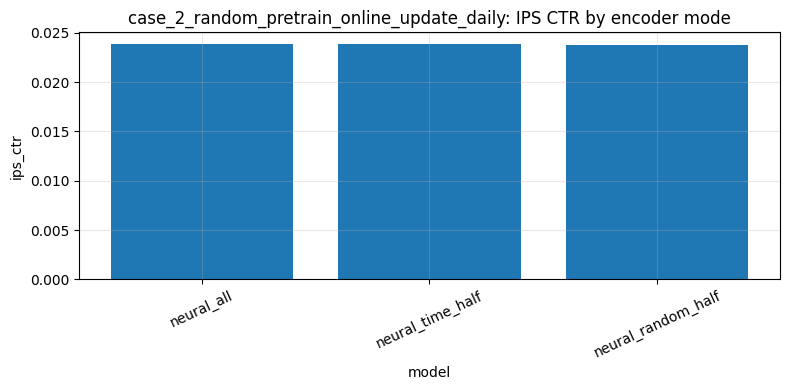

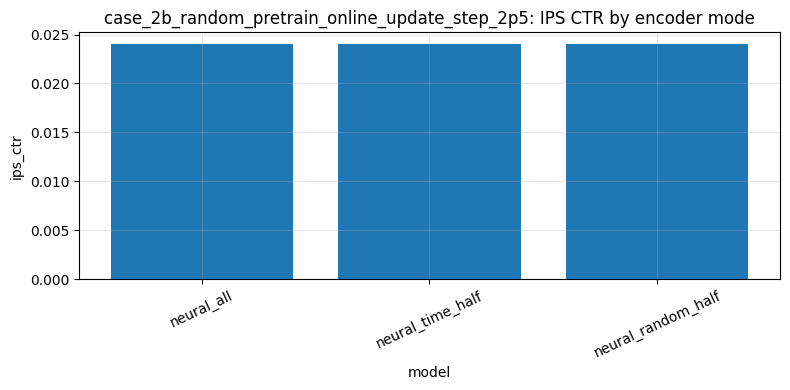

In [11]:
if not neural_metrics.empty:
    for scenario_name, part in neural_metrics.groupby('scenario'):
        fig, ax = plt.subplots(figsize=(8, 4))
        part = part.sort_values('ips_ctr', ascending=False)
        ax.bar(part['algo'], part['ips_ctr'])
        ax.set_title(f'{scenario_name}: IPS CTR by encoder mode')
        ax.set_xlabel('model')
        ax.set_ylabel('ips_ctr')
        ax.tick_params(axis='x', rotation=25)
        ax.grid(True, alpha=0.3)
        fig.tight_layout()
        plt.show()
else:
    print('No neural metrics to plot.')


## 7) Embedding quality analysis (2D projection by action/reward)
Для каждого action строится 2D проекция выходов энкодера; цвет: `reward=0` vs `reward=1`.


/Users/ogrobertino/BanditsResearch/src/bandit_benchmark.py:777: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  x = torch.as_tensor(X, dtype=torch.float32)


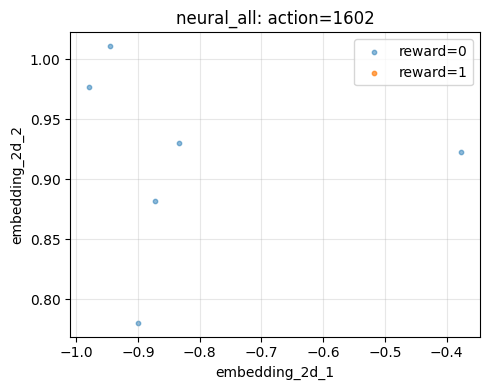

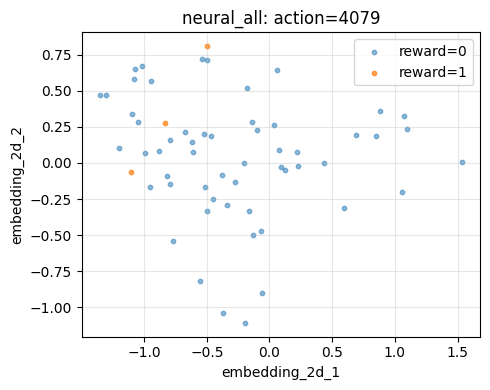

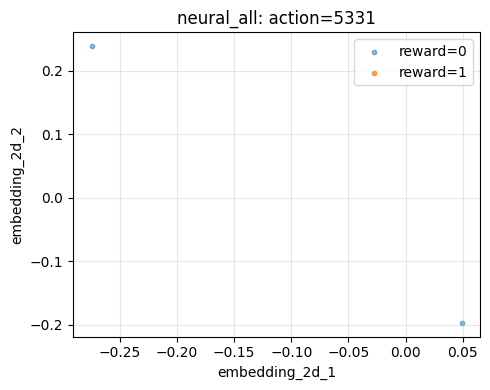

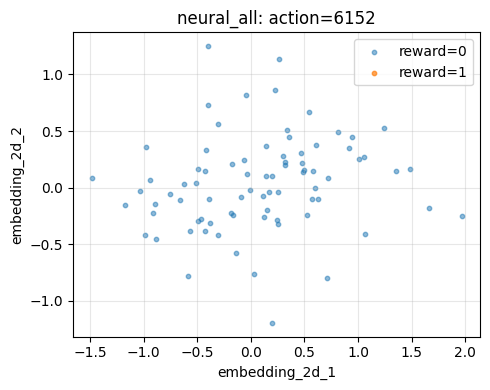

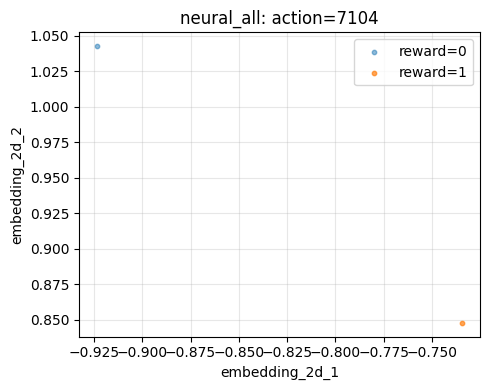

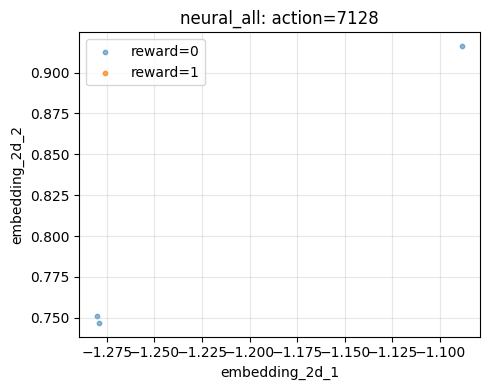

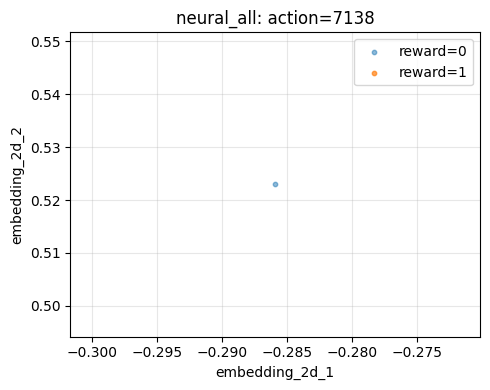

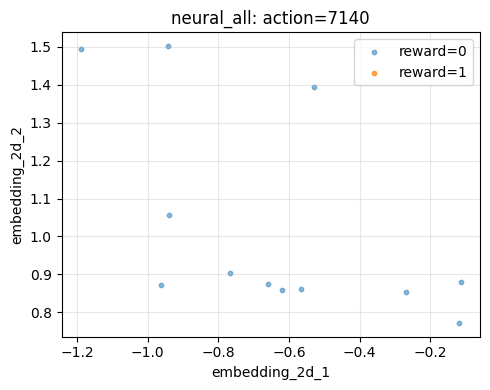

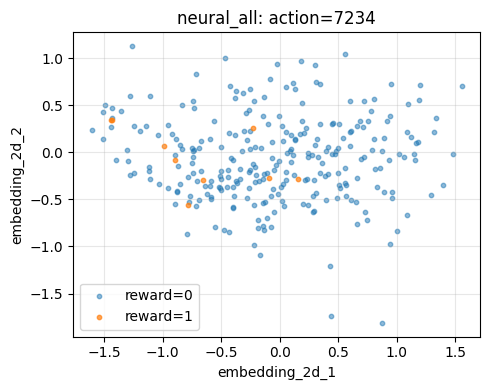

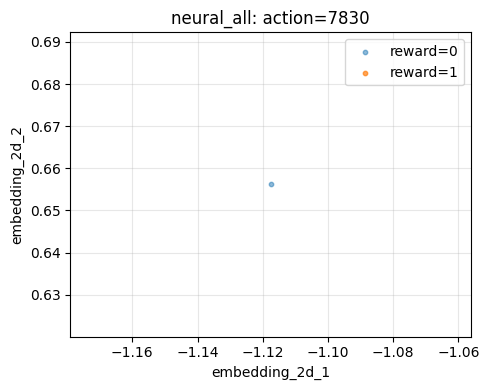

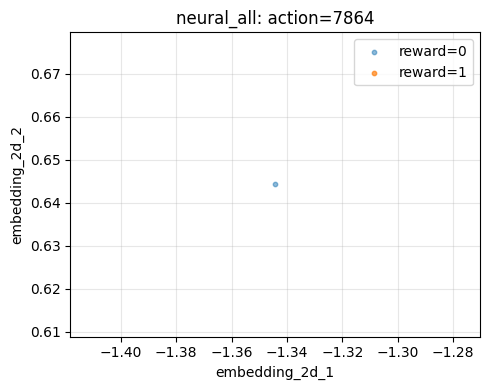

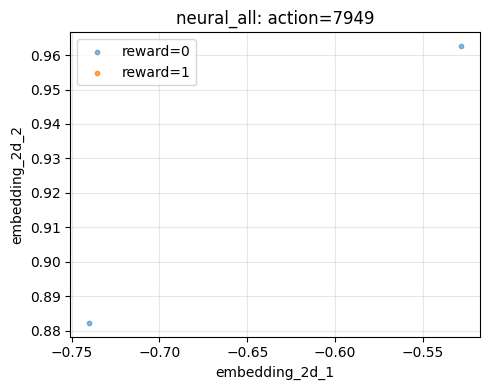

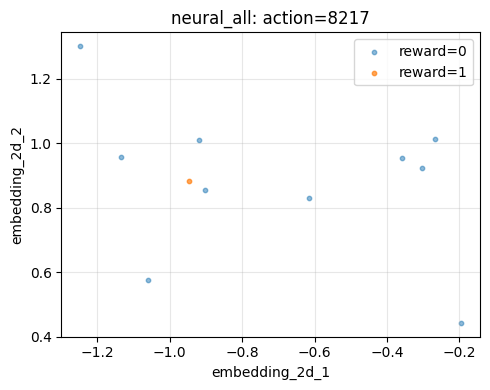

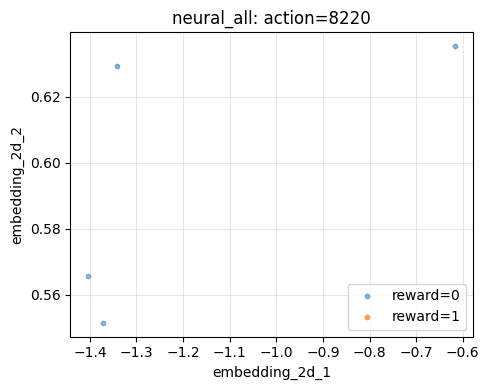

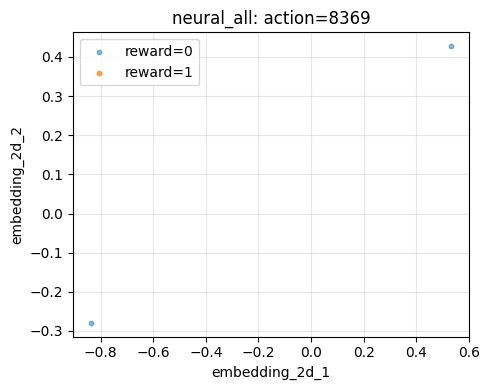

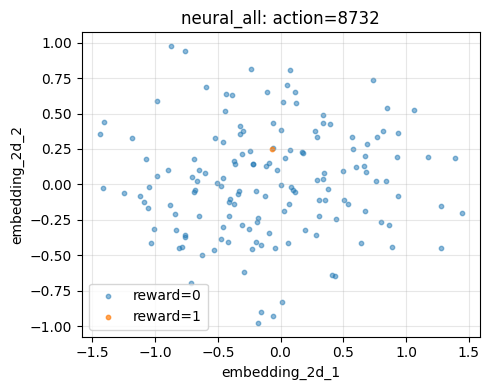

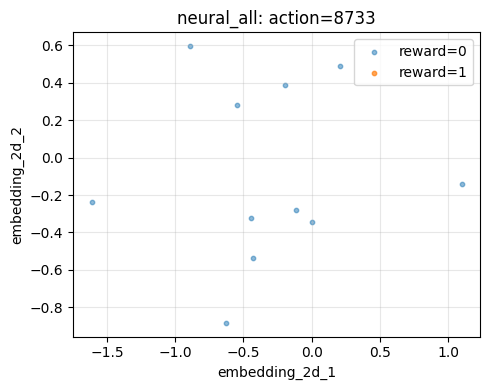

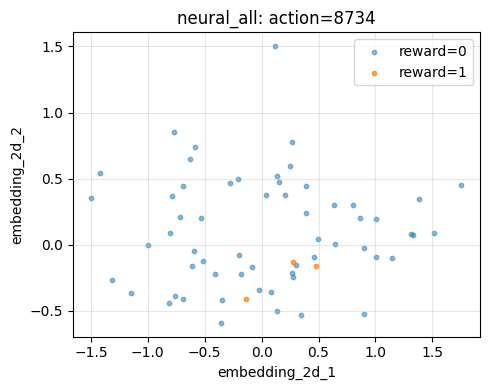

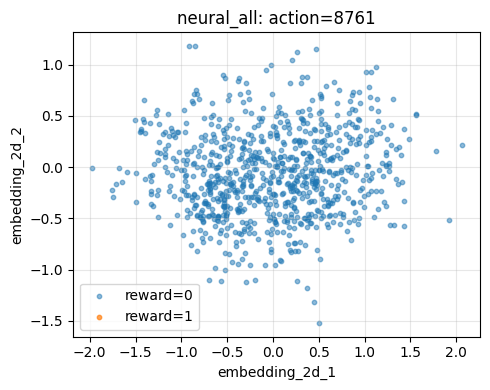

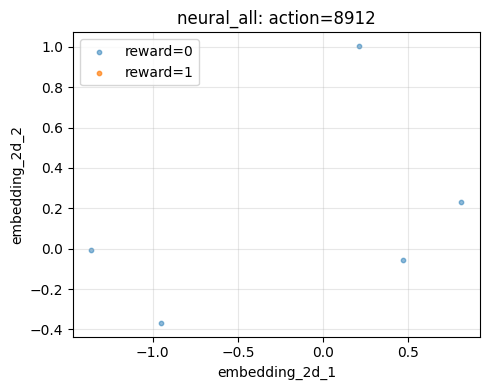

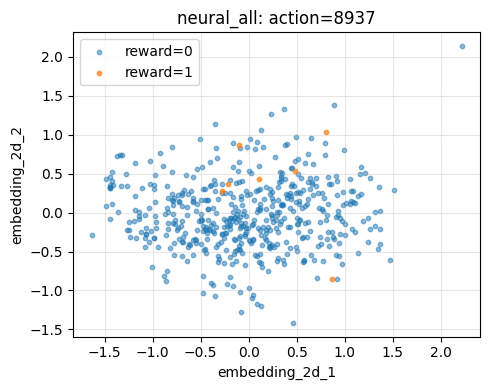

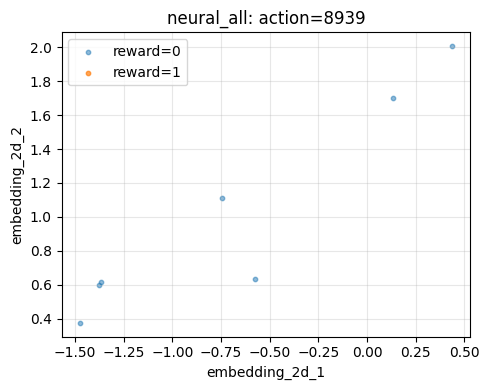

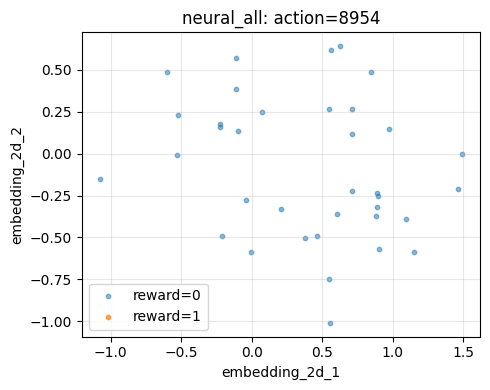

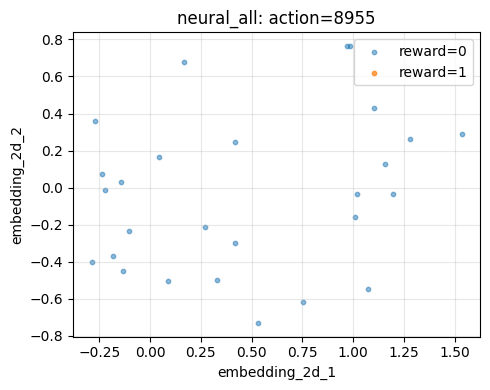

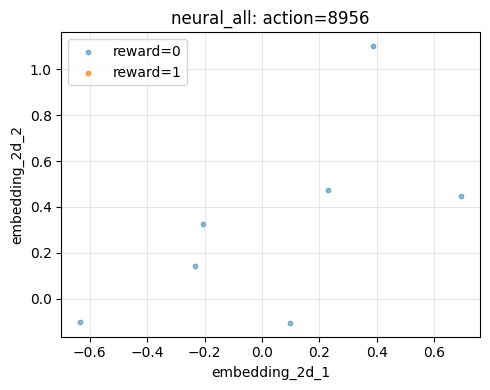

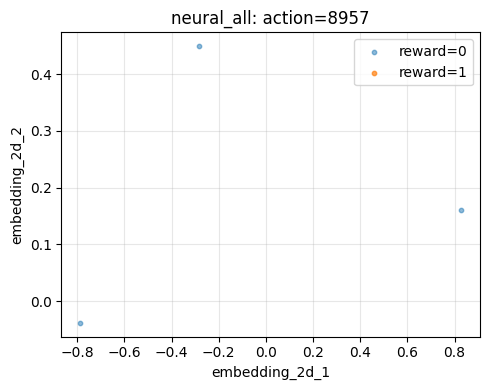

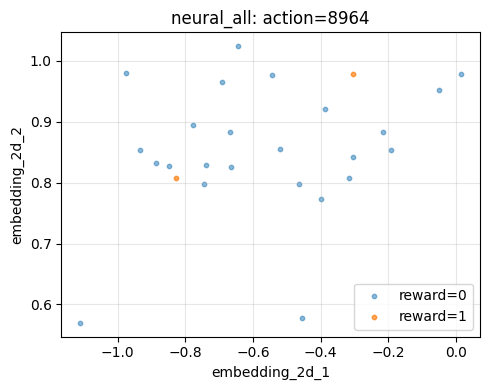

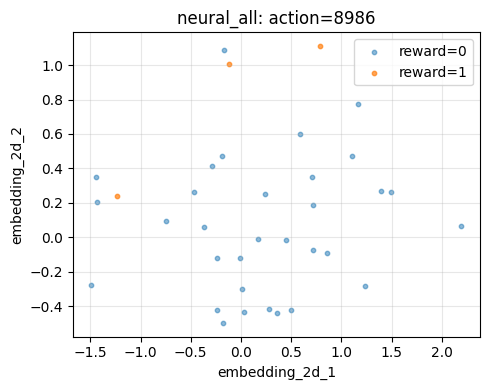

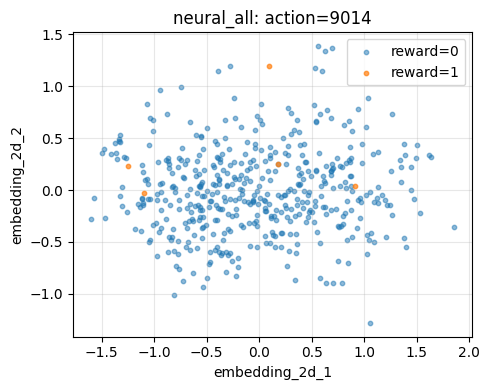

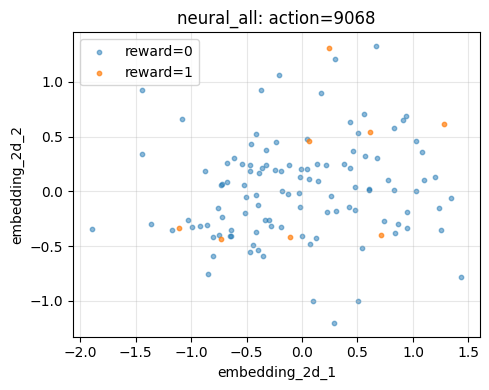

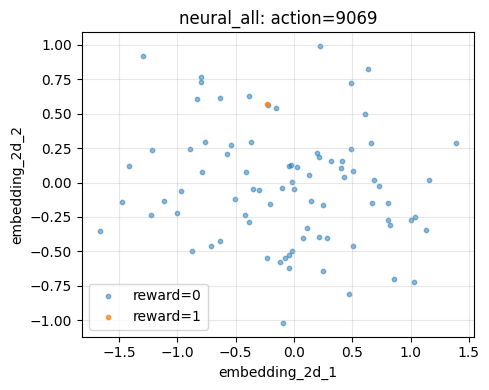

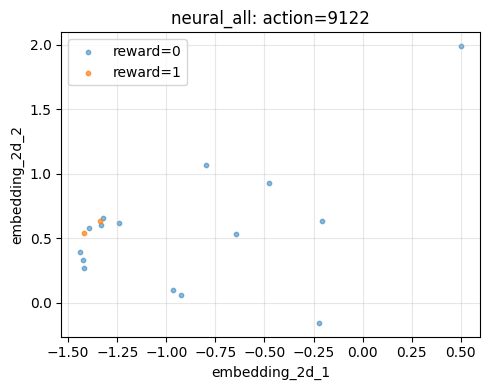

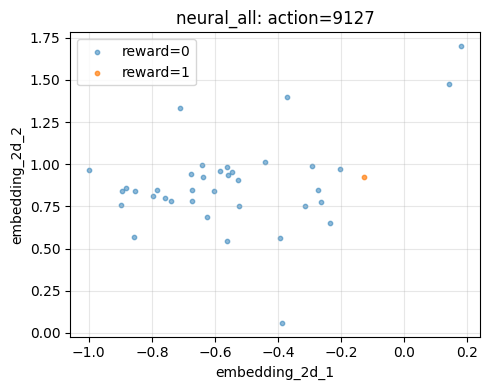

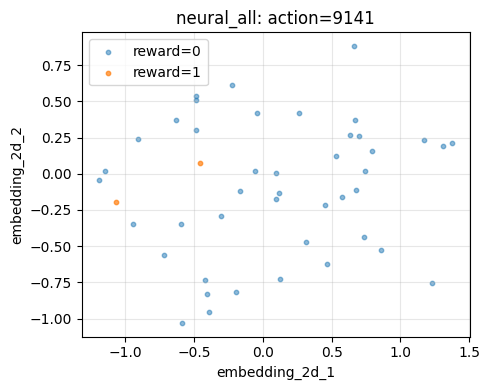

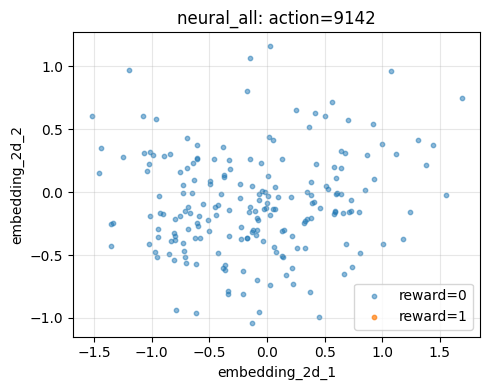

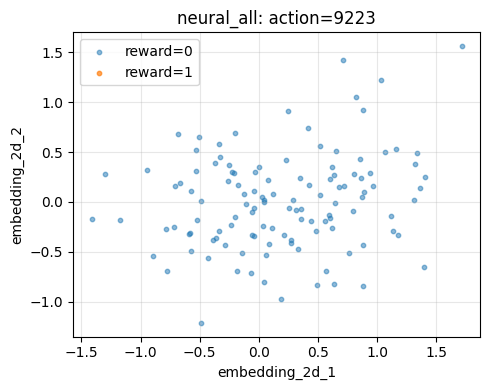

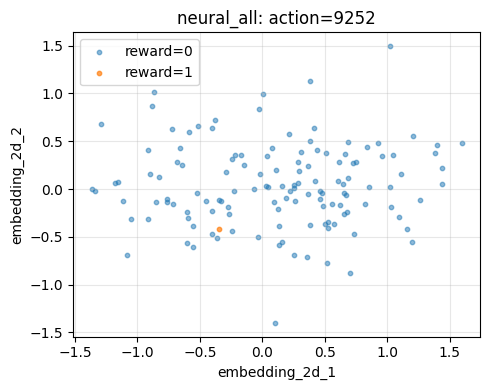

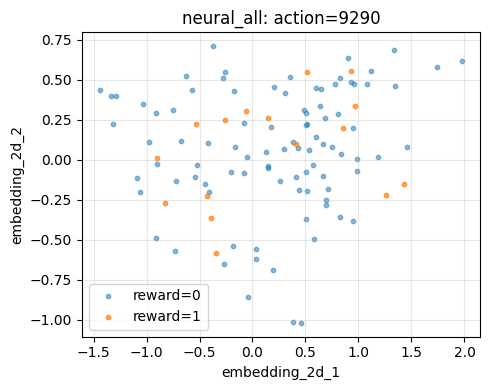

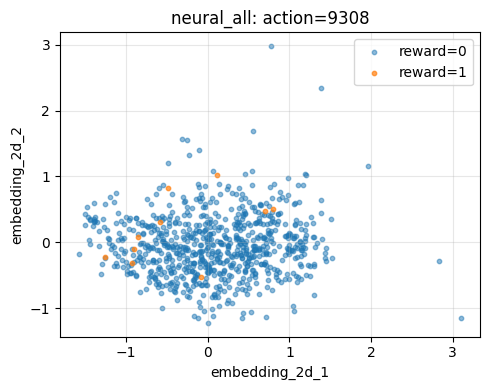

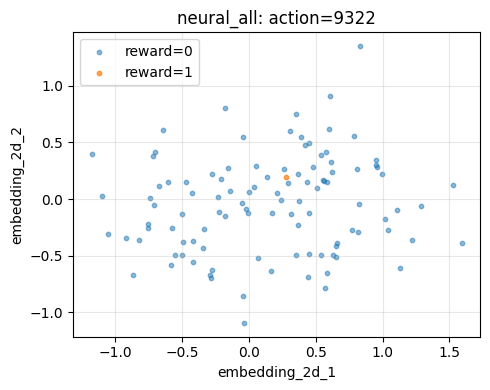

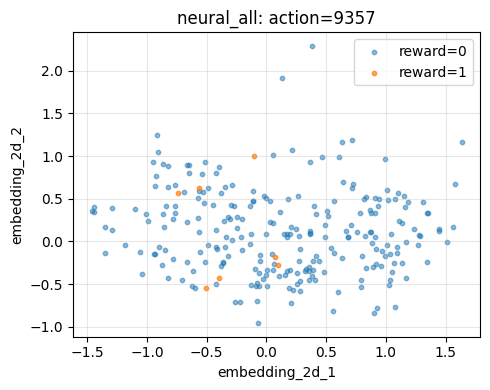

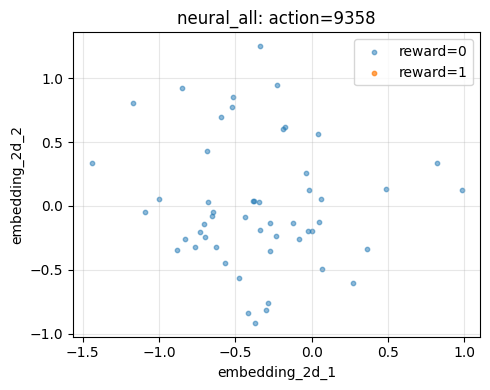

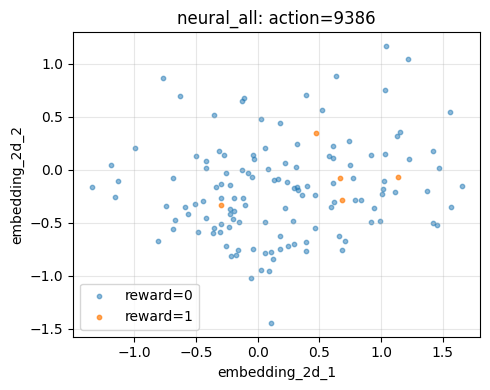

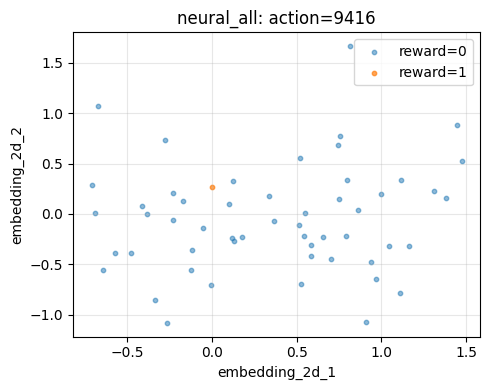

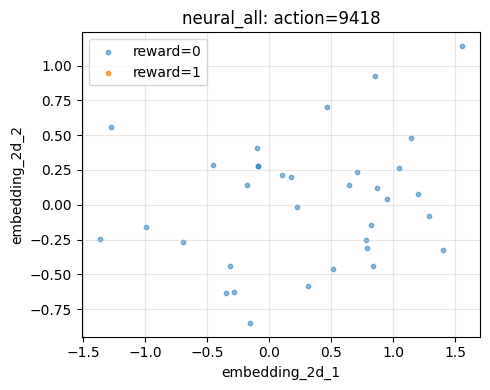

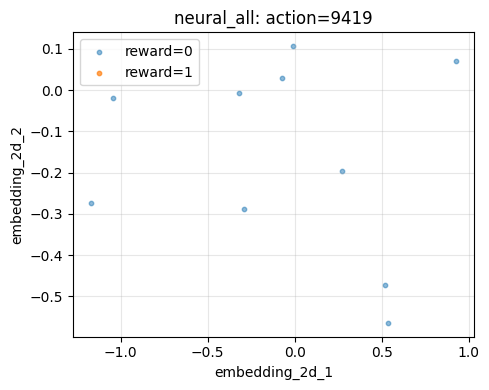

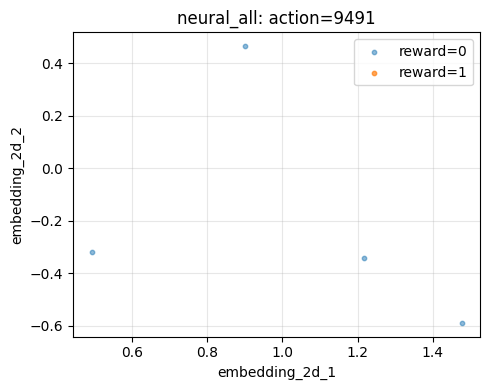

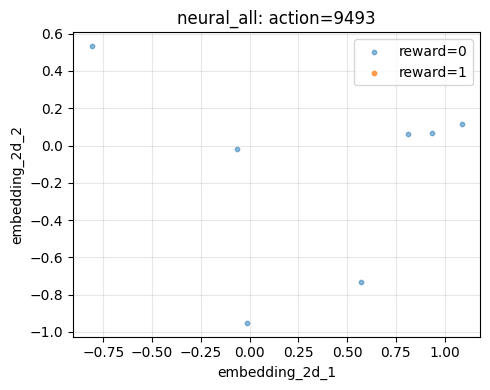

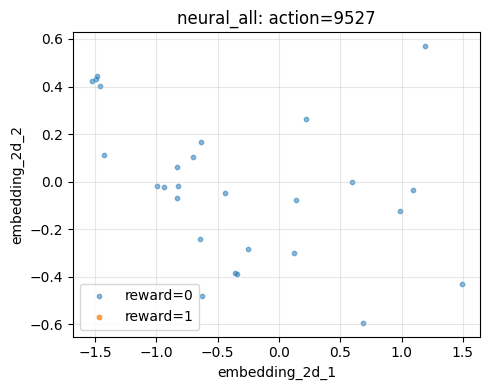

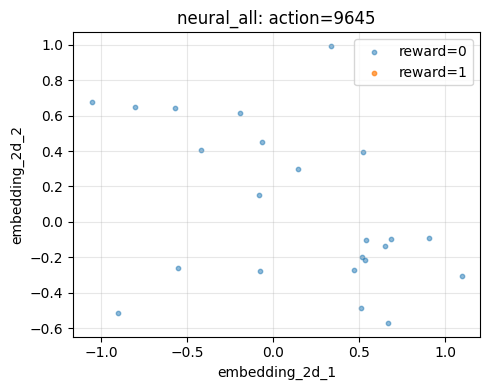

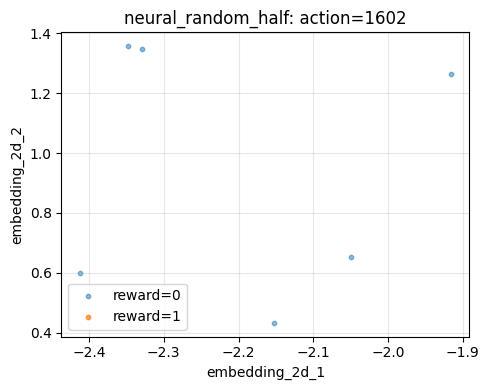

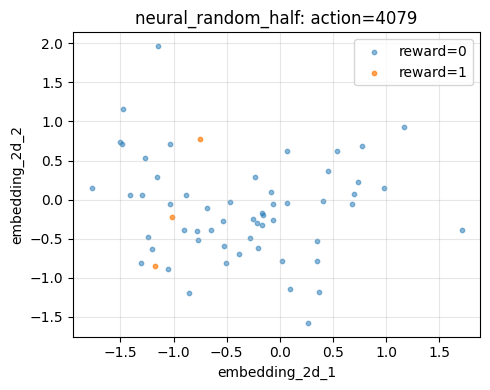

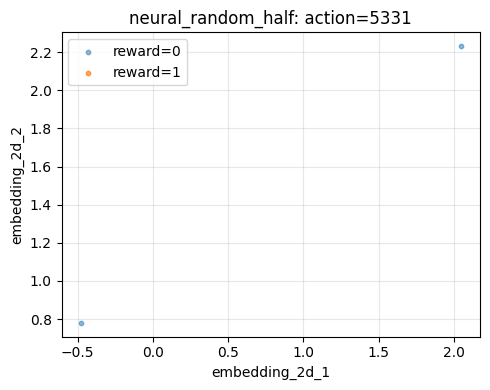

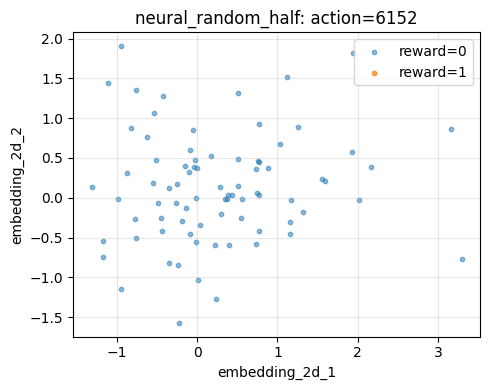

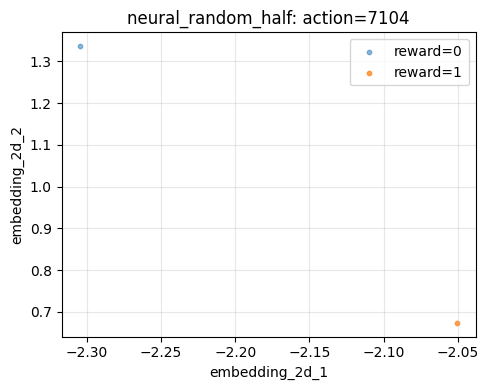

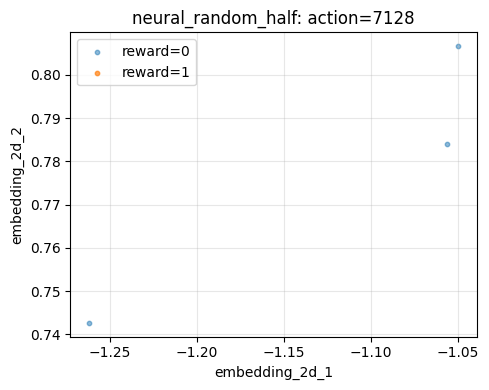

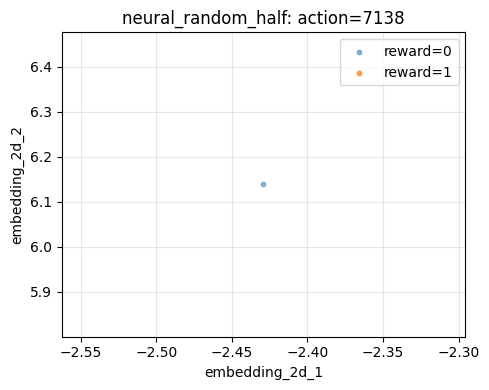

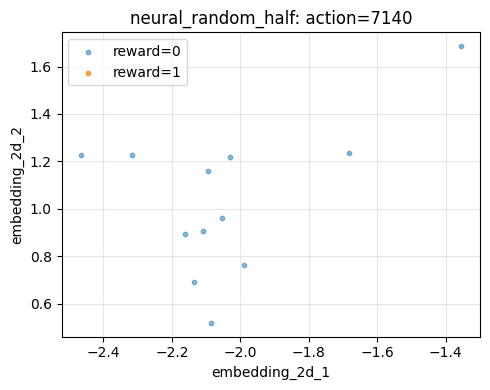

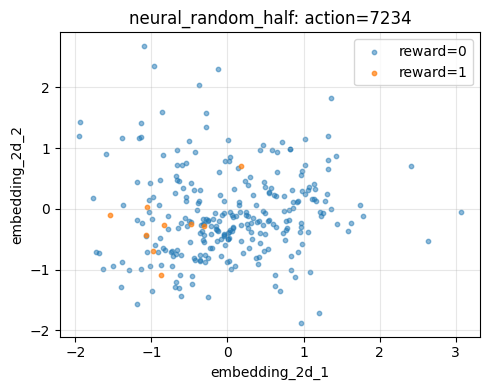

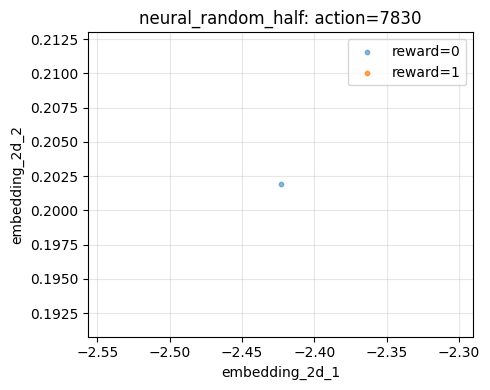

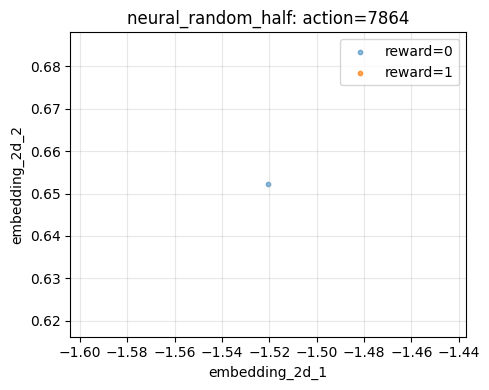

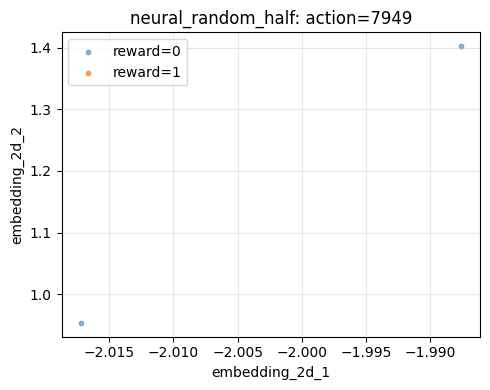

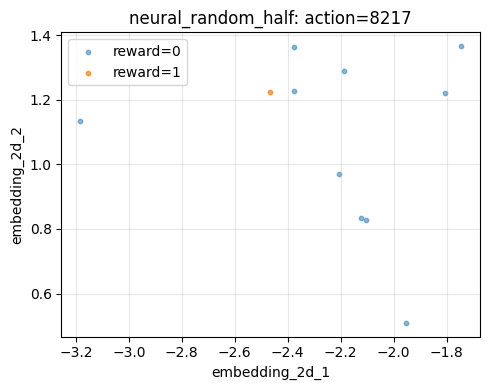

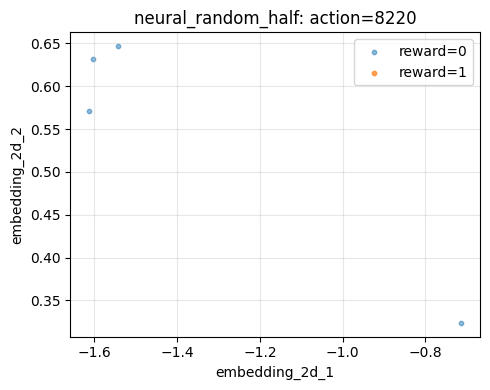

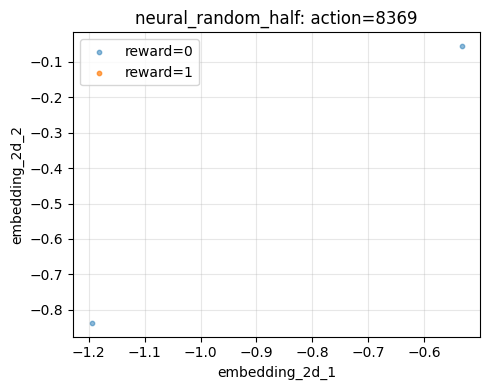

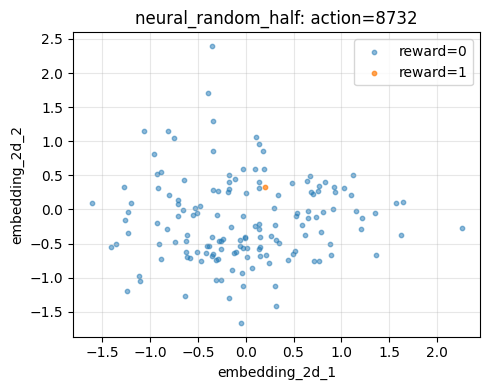

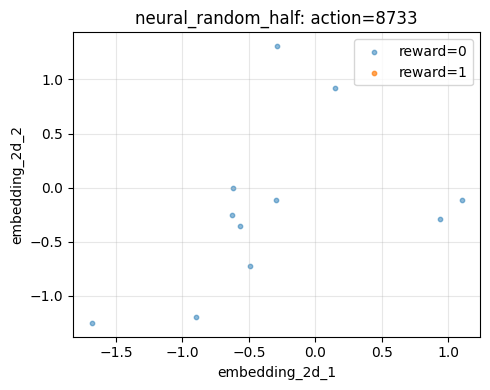

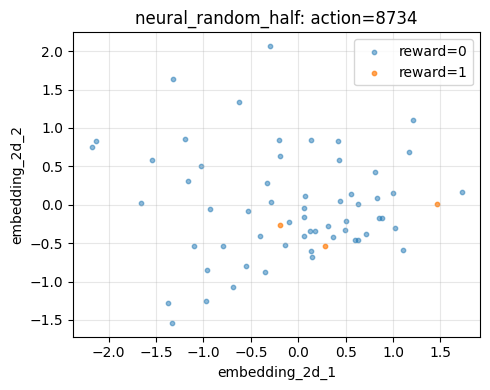

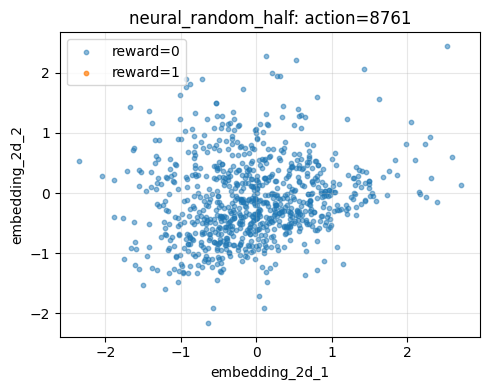

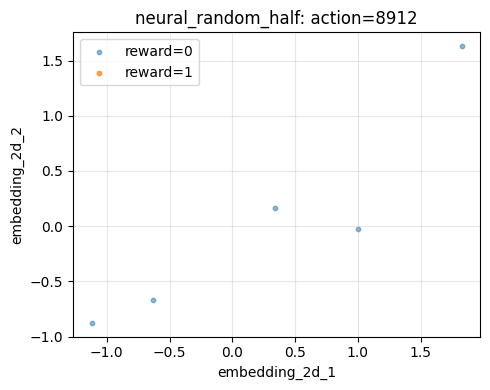

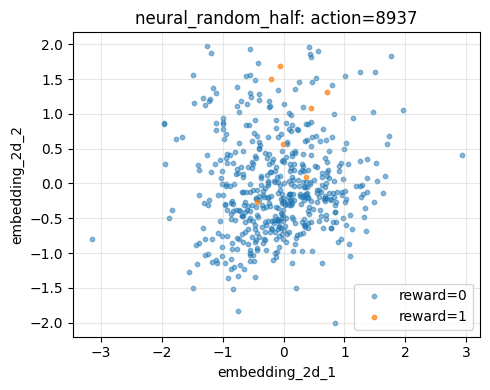

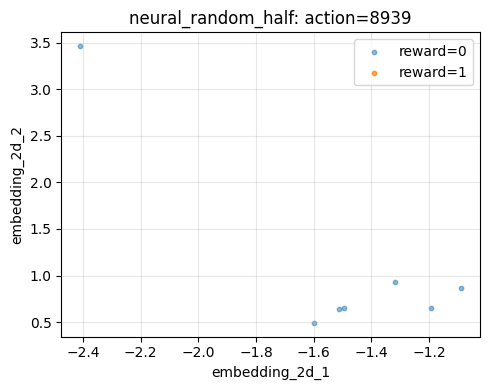

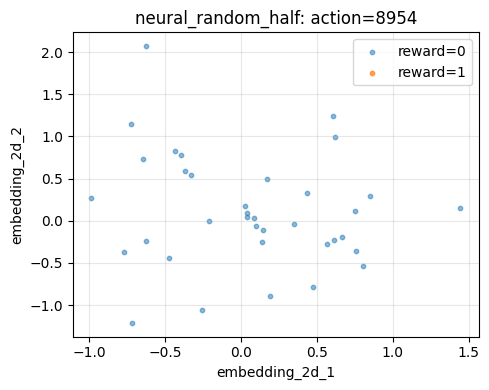

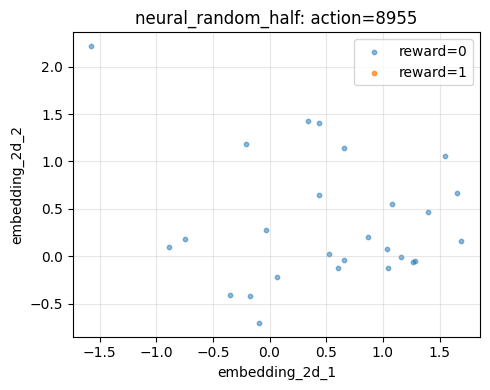

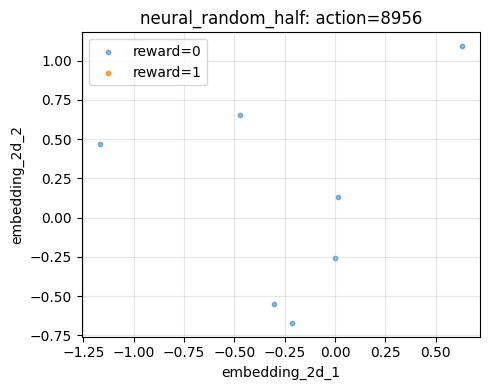

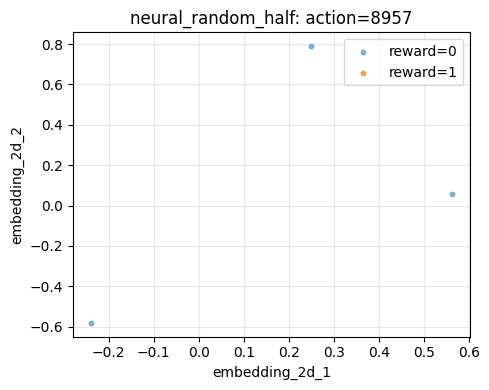

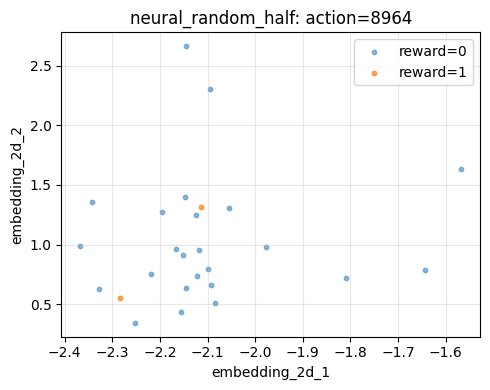

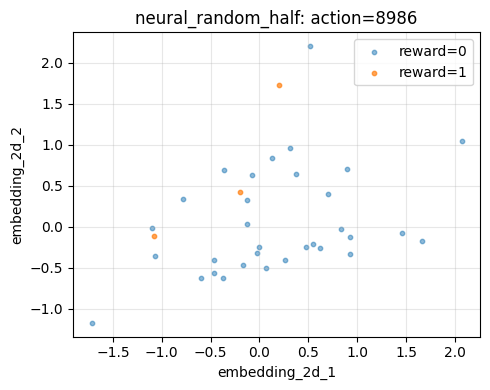

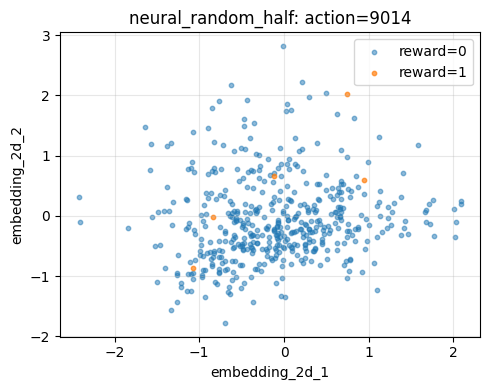

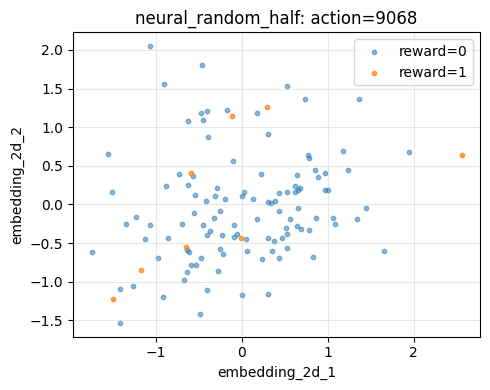

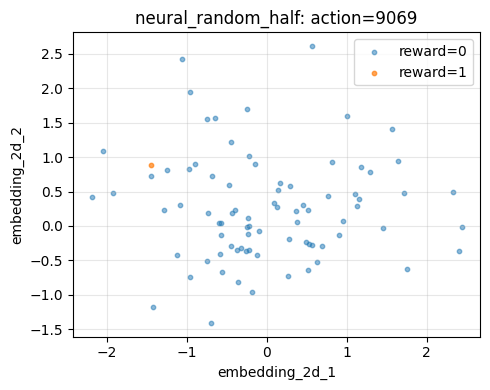

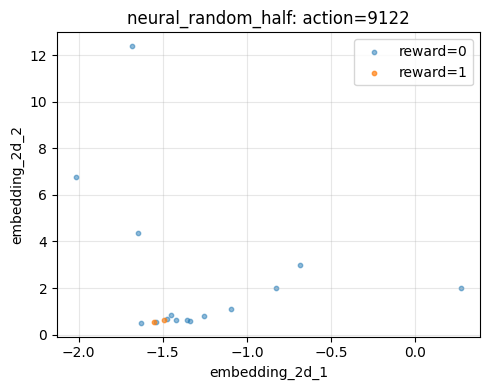

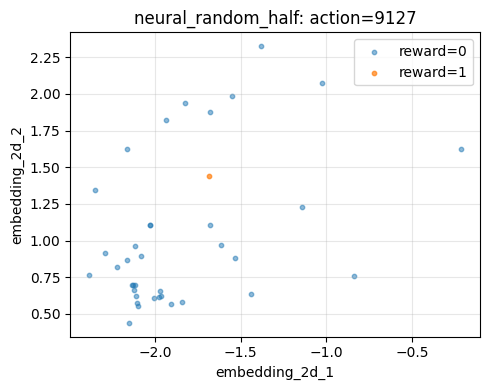

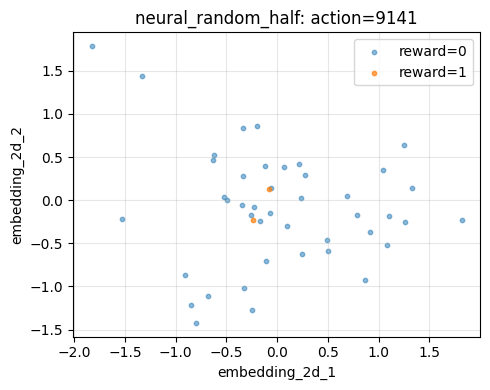

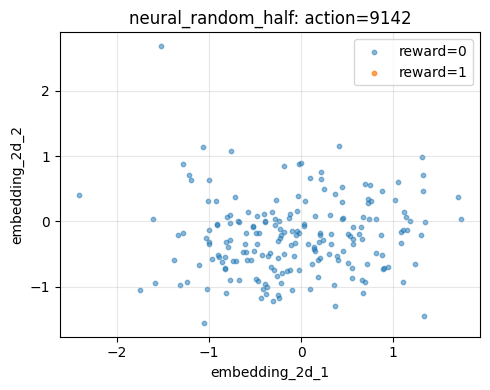

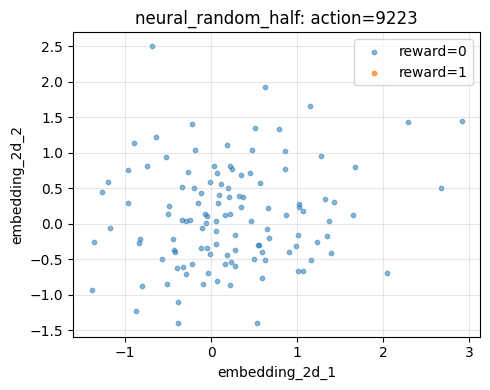

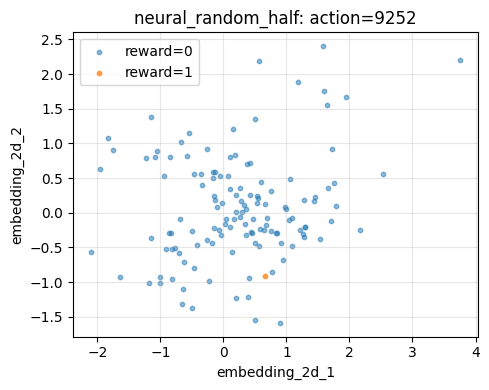

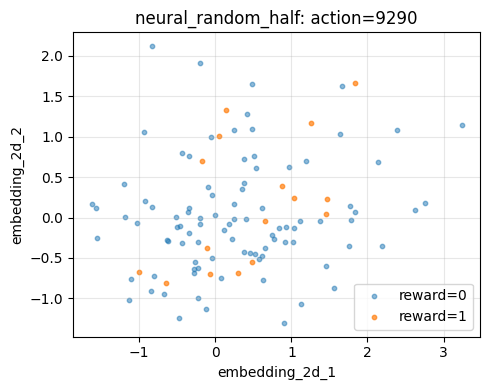

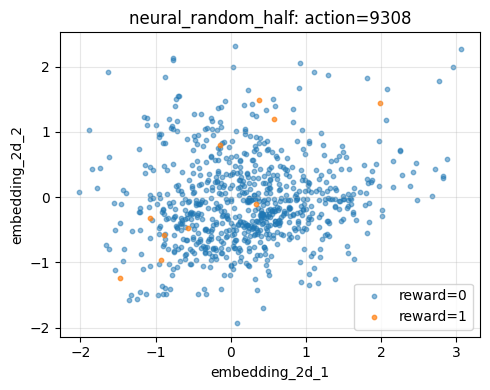

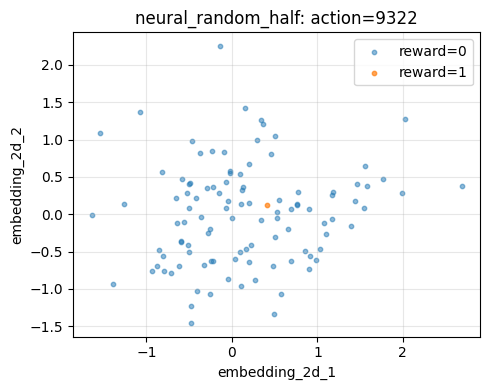

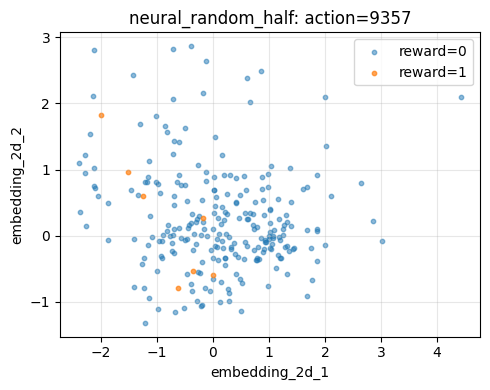

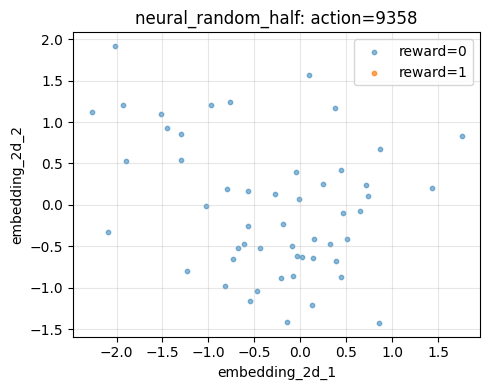

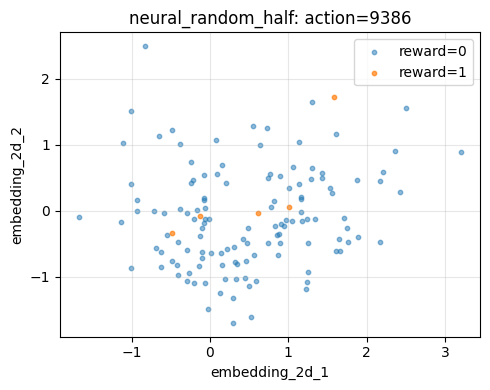

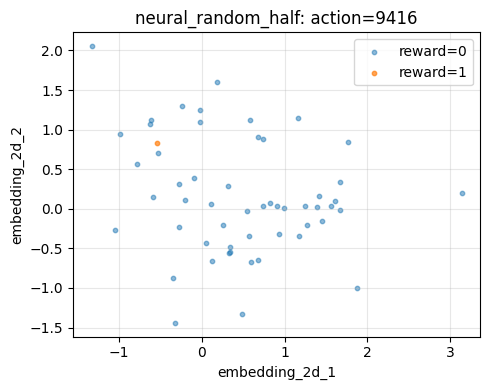

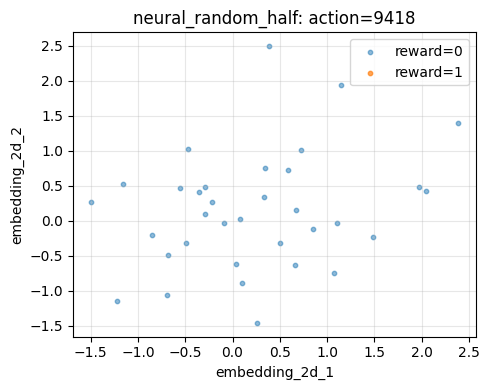

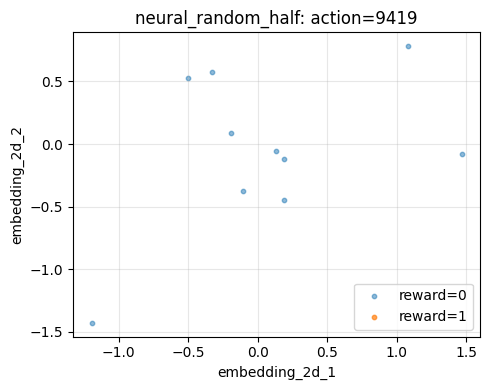

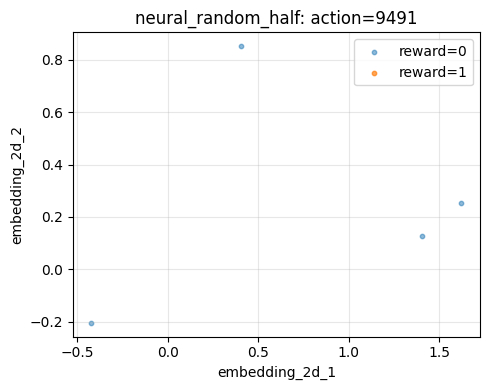

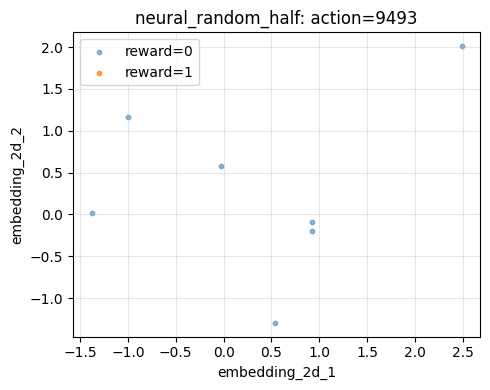

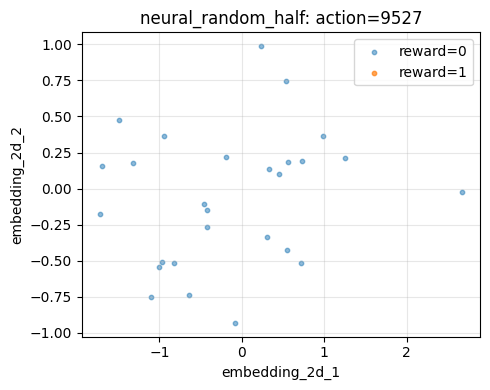

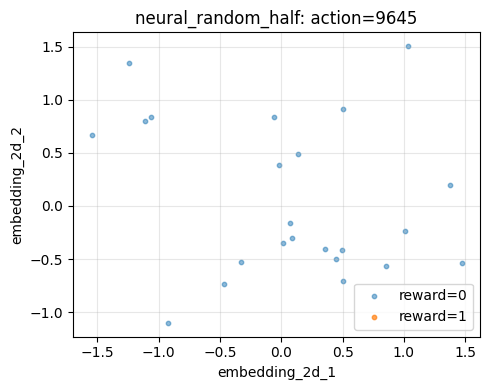

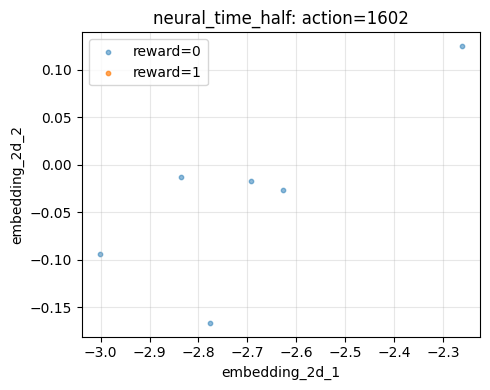

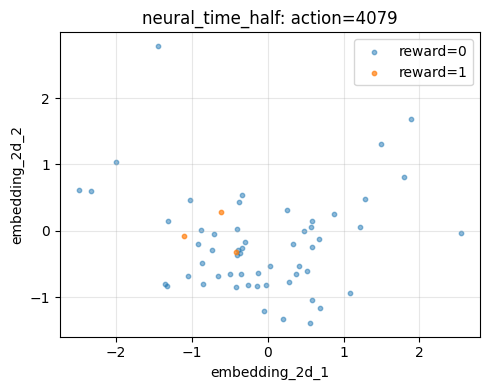

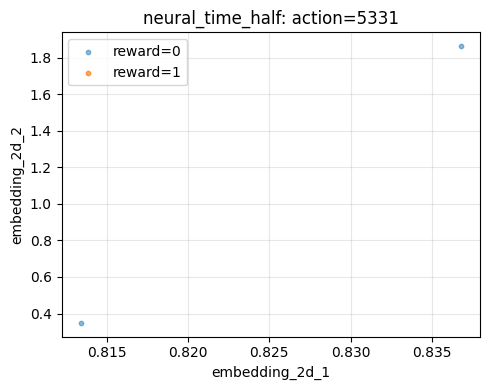

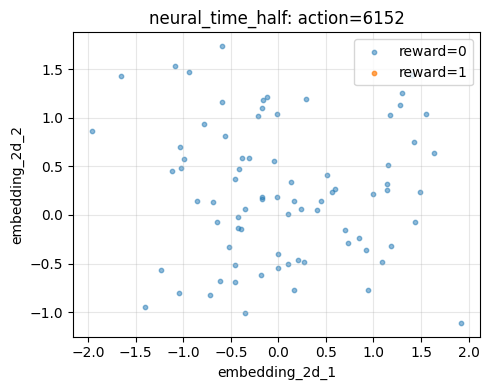

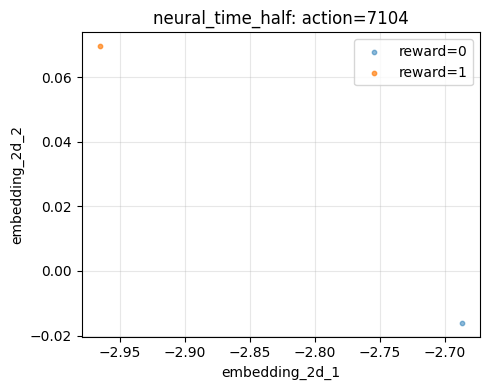

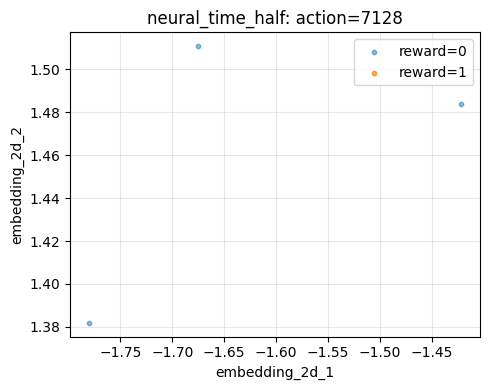

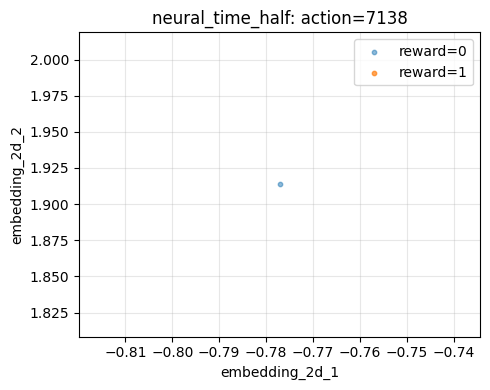

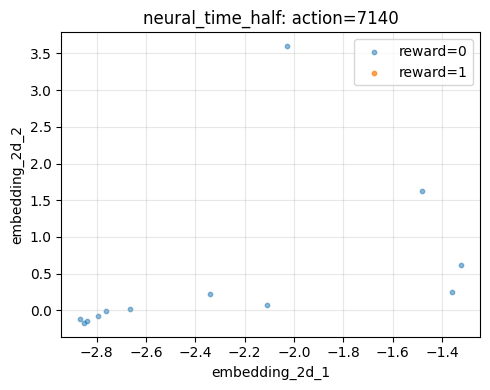

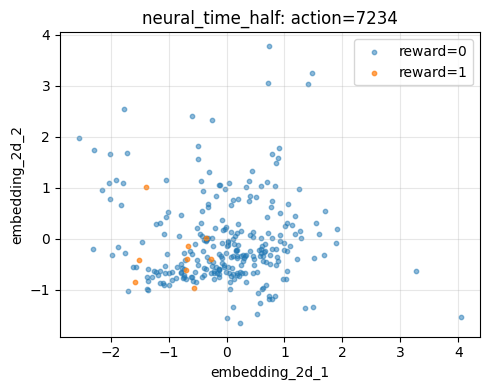

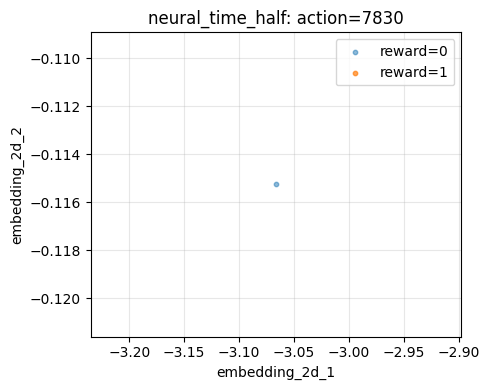

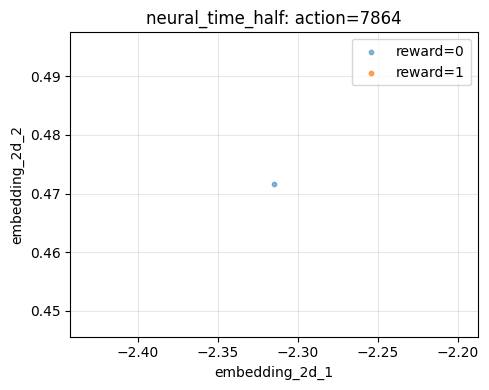

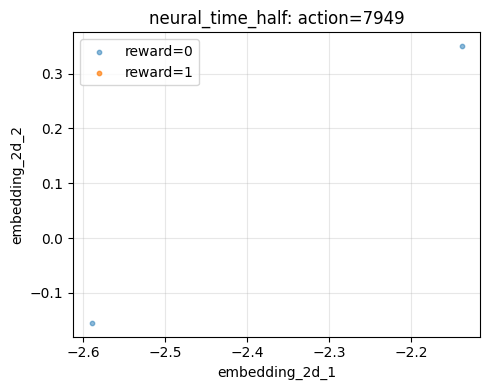

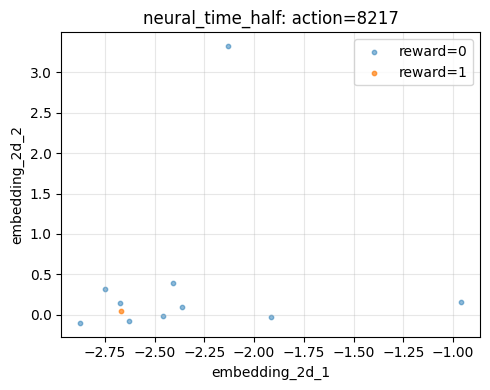

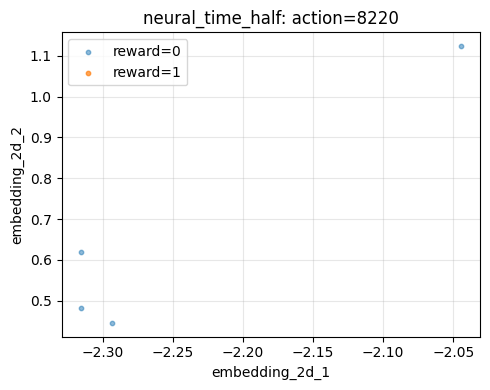

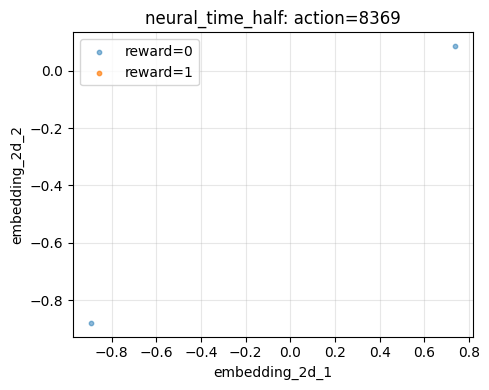

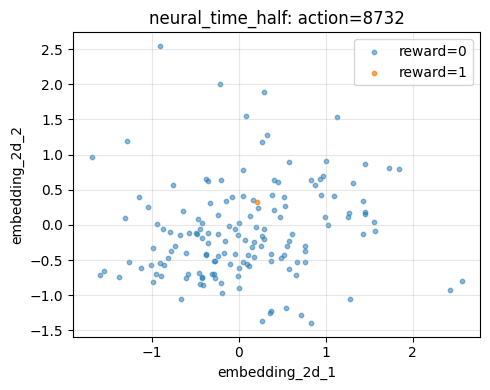

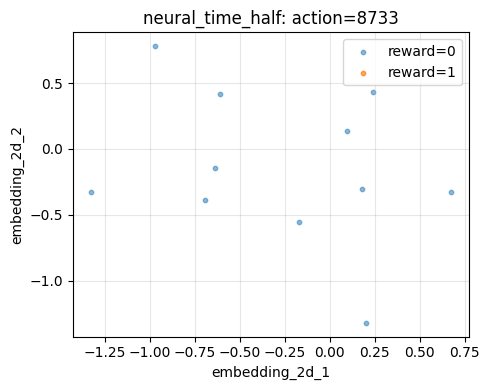

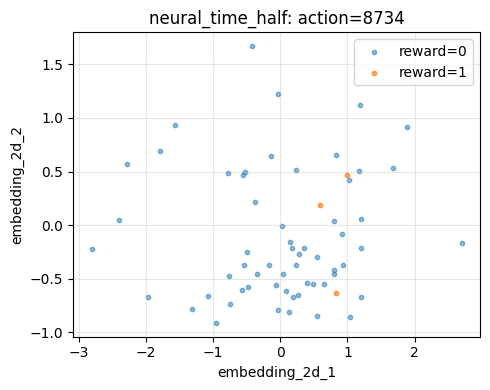

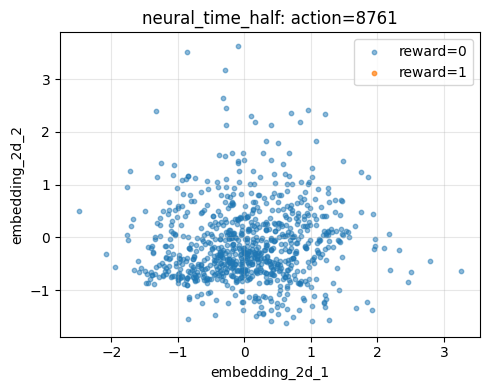

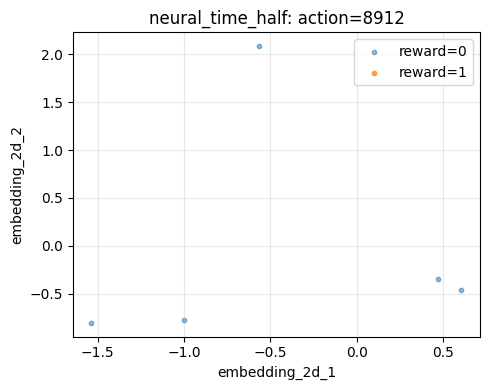

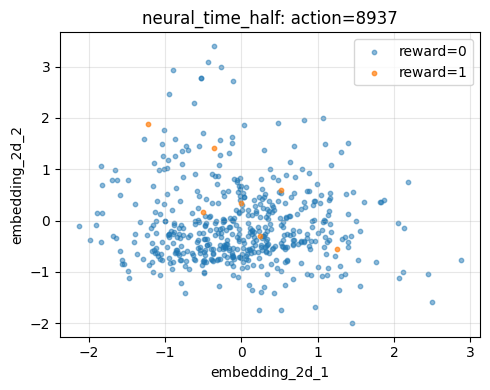

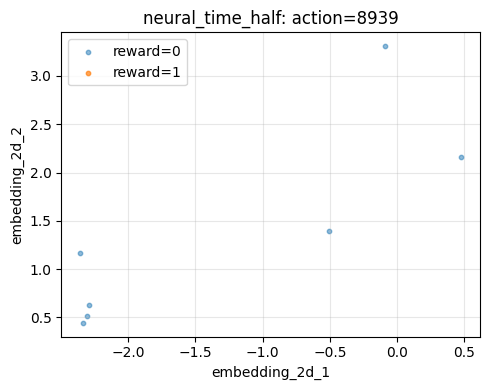

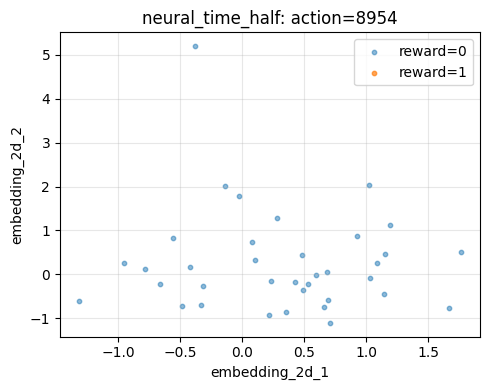

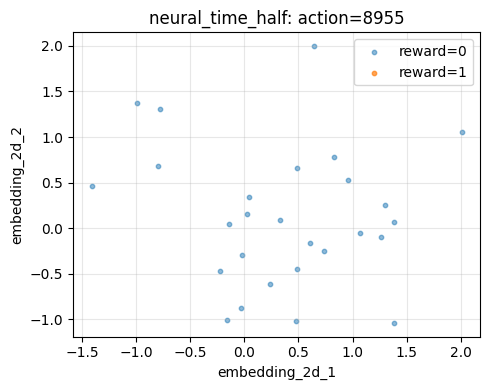

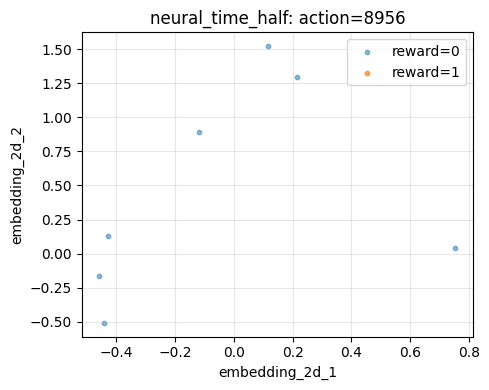

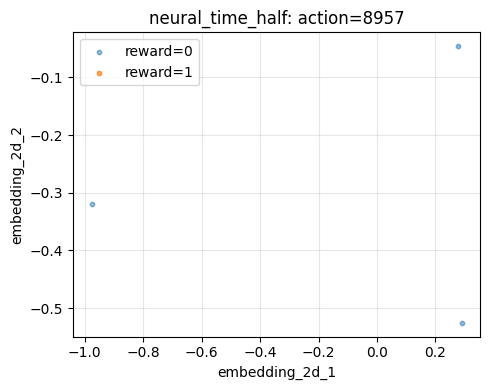

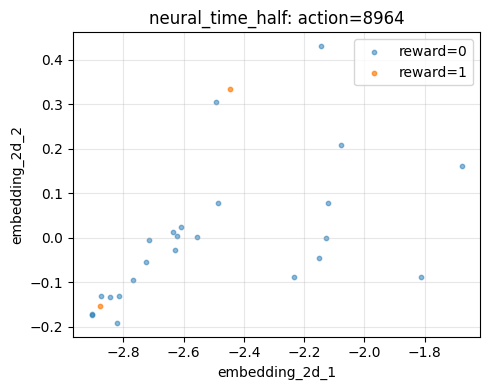

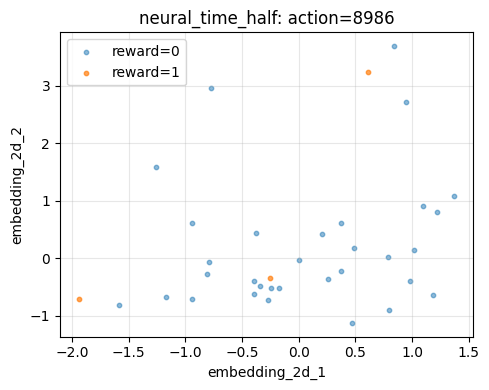

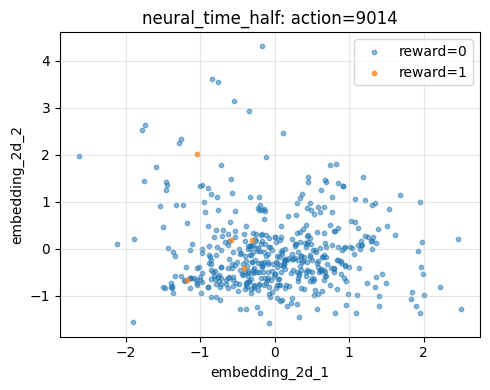

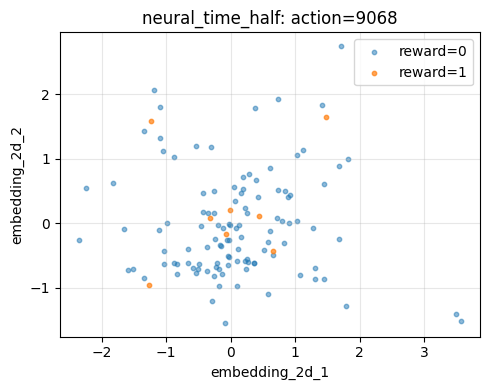

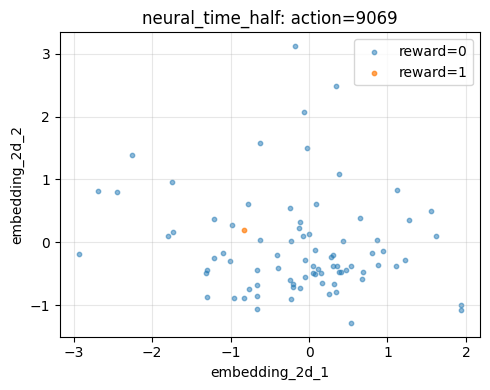

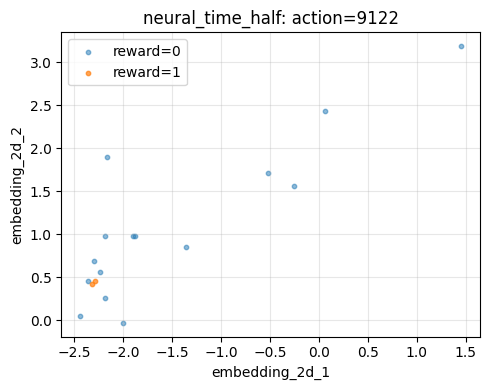

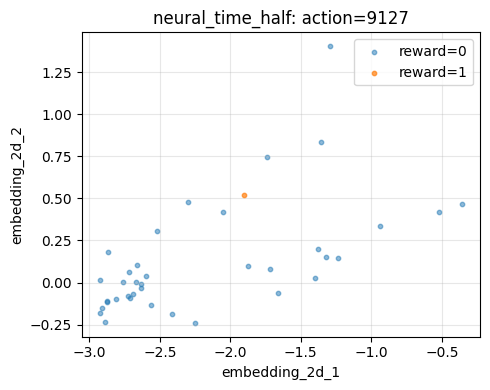

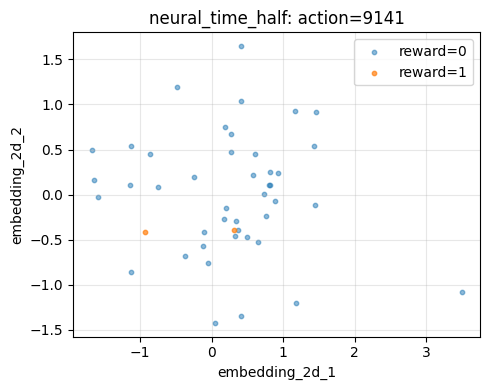

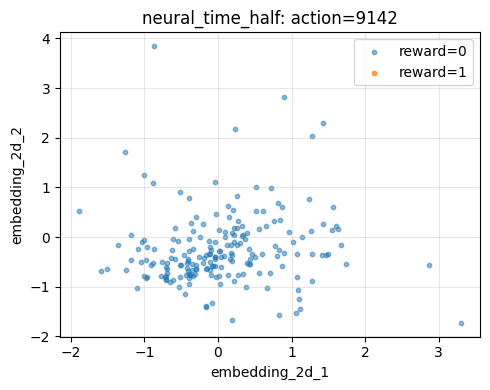

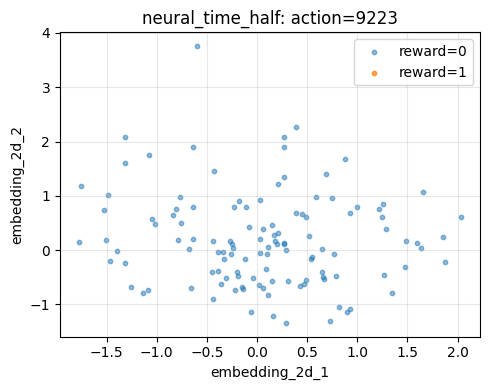

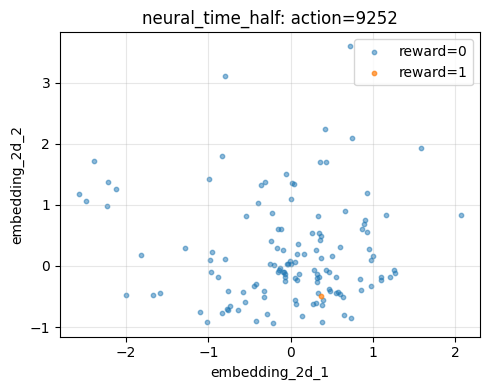

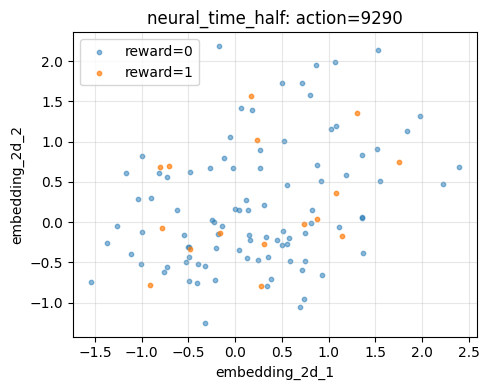

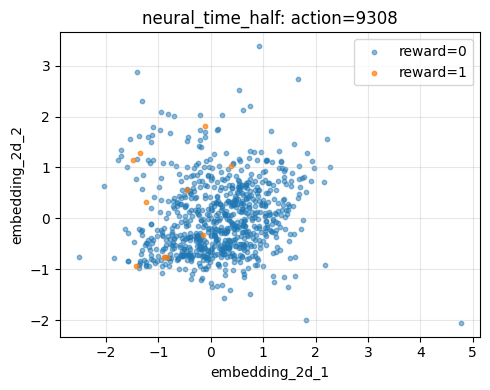

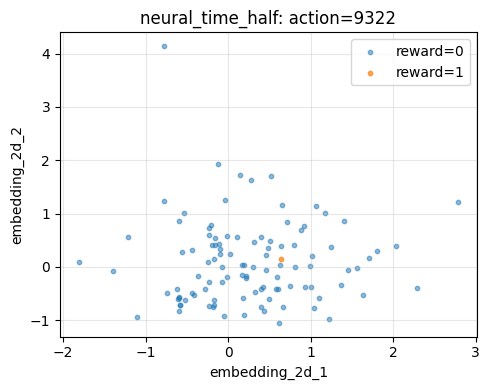

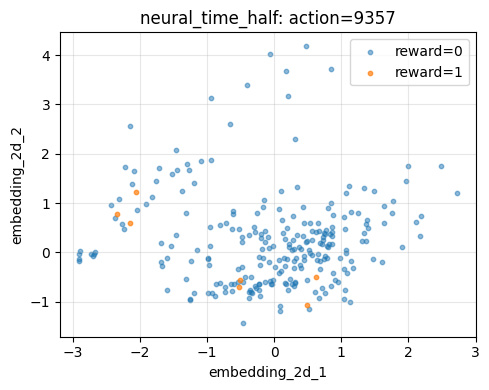

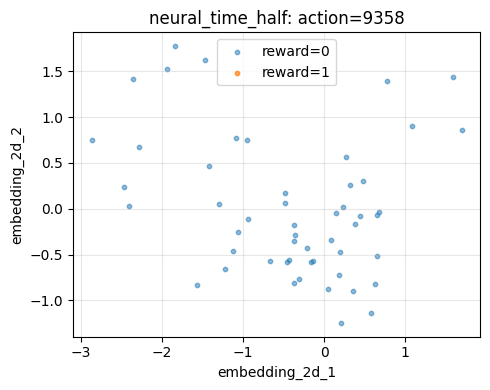

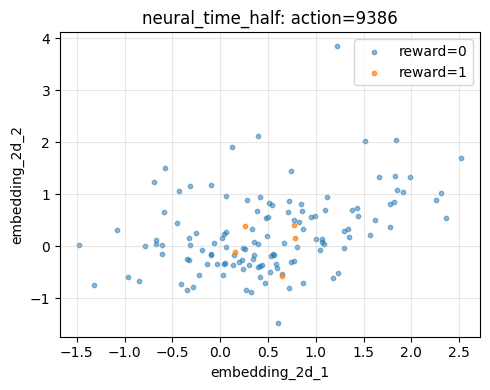

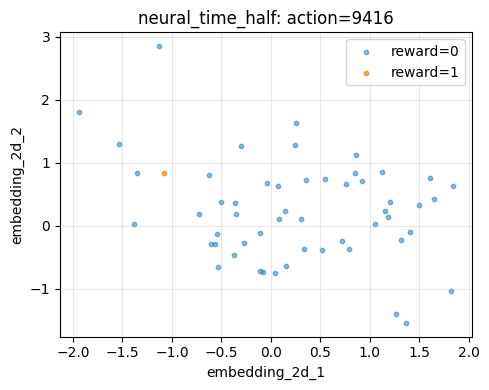

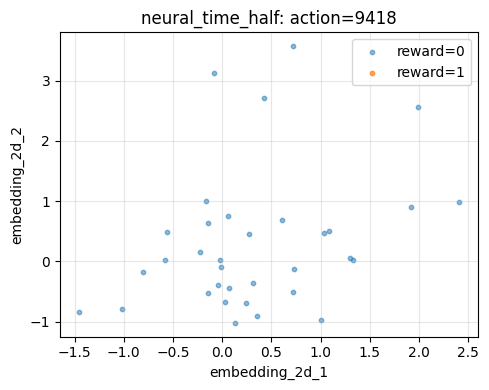

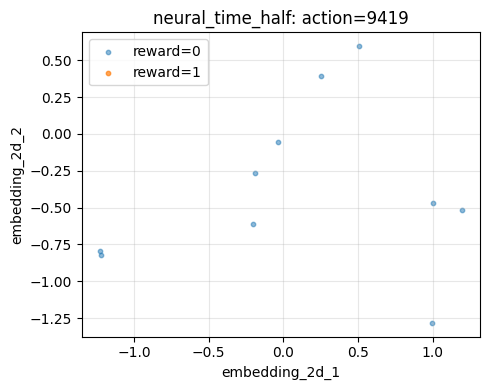

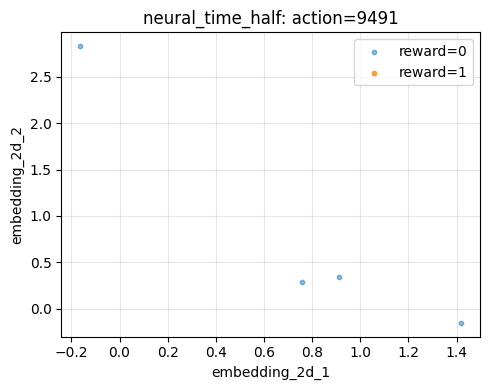

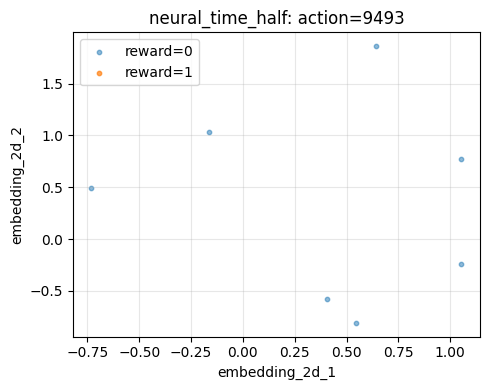

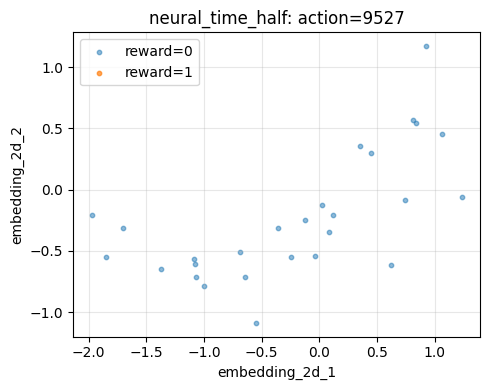

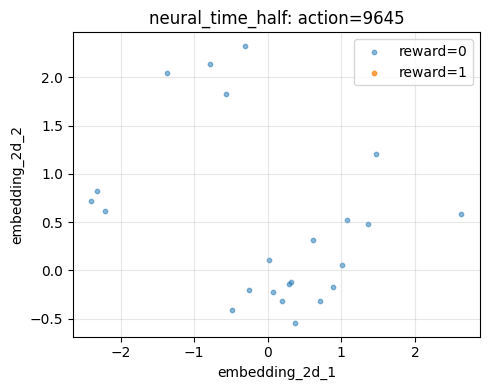

In [12]:
encoder_modes = ['neural_all', 'neural_random_half', 'neural_time_half']
MAX_ROWS = 5000
MAX_ACTIONS_PLOT = None  # например 10, чтобы ограничить число графиков

sample_pdf = test_df.to_pandas().copy()
if len(sample_pdf) > MAX_ROWS:
    sample_pdf = sample_pdf.sample(n=MAX_ROWS, random_state=SEED).reset_index(drop=True)

X = sample_pdf['features_list'].tolist()
actions = sample_pdf['show'].astype(int).to_numpy()
rewards = (sample_pdf['reward'].astype(float) > 0).astype(int).to_numpy()

for mode in encoder_modes:
    # берем первую доступную сценарию/модель
    policy_obj = None
    for scenario_name, models in trained_models.items():
        if mode in models:
            policy_obj = models[mode]
            break

    if policy_obj is None or getattr(policy_obj, '_encoder', None) is None:
        print(f'{mode}: encoder not available')
        continue

    Z = policy_obj._encoder.transform(X)

    try:
        from sklearn.decomposition import PCA
        Z2 = PCA(n_components=2, random_state=SEED).fit_transform(Z)
    except Exception:
        Z2 = Z[:, :2] if Z.shape[1] >= 2 else __import__('numpy').c_[Z[:, 0], Z[:, 0] * 0]

    emb_df = pd.DataFrame({
        'z1': Z2[:, 0],
        'z2': Z2[:, 1],
        'action': actions,
        'reward01': rewards,
    })

    action_values = sorted(emb_df['action'].unique())
    if MAX_ACTIONS_PLOT is not None:
        action_values = action_values[:MAX_ACTIONS_PLOT]

    for a in action_values:
        part = emb_df[emb_df['action'] == a]
        if part.empty:
            continue

        fig, ax = plt.subplots(figsize=(5, 4))
        part0 = part[part['reward01'] == 0]
        part1 = part[part['reward01'] == 1]

        ax.scatter(part0['z1'], part0['z2'], s=10, alpha=0.5, label='reward=0')
        ax.scatter(part1['z1'], part1['z2'], s=10, alpha=0.7, label='reward=1')

        ax.set_title(f'{mode}: action={a}')
        ax.set_xlabel('embedding_2d_1')
        ax.set_ylabel('embedding_2d_2')
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        plt.show()



## 8) Save comparison artifacts


In [13]:
OUT_DIR = ARTIFACTS_DIR / 'encoder_mode_compare'
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT_DIR / 'metrics_compare.csv'
history_path = OUT_DIR / 'history_compare.csv'

metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)

print('saved:', metrics_path)
print('saved:', history_path)


saved: /Users/ogrobertino/BanditsResearch/artifacts/cdp_music_fs_small/encoder_mode_compare/metrics_compare.csv
saved: /Users/ogrobertino/BanditsResearch/artifacts/cdp_music_fs_small/encoder_mode_compare/history_compare.csv
